### Mounting notebook from drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir("/content/drive/MyDrive/Project/Legal-Risk-Identifier")

### Importing Libraries

In [5]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Validation Data

In [6]:
val_df = pd.read_csv("data/processed/val.csv")
val_df.head()

,text,label
0,"1.1.2 xli grants wcc a limited, non-exclusive,...",0.0
1,"customer hereby grants to ibm, its affiliates ...",1.0
2,franchisee agrees and grants to pretzel time a...,1.0
3,purchaser and sony are referred to individuall...,0.0
4,"notwithstanding paragraphs 4a, 4b and 4c above...",2.0


### Loading trained model

In [7]:
MODEL_PATH = "models/bert_legal_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Dataset Classes

In [8]:
class LegalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx])
        }

### Creating Data Loaders

In [9]:
val_dataset = LegalDataset(
    val_df["text"].tolist(),
    val_df["label"].tolist(),
    tokenizer
)

val_loader = DataLoader(val_dataset, batch_size=16)

## Metrics & Confusion matric - Evaluation

### Predictions

In [10]:
preds = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(batch["labels"].numpy())

### Classification Report

In [11]:
print(classification_report(
    true_labels,
    preds,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.87      0.90      0.88       435
      Medium       0.80      0.82      0.81       302
        High       0.85      0.79      0.82       301

    accuracy                           0.84      1038
   macro avg       0.84      0.84      0.84      1038
weighted avg       0.84      0.84      0.84      1038



### Confusion Matric

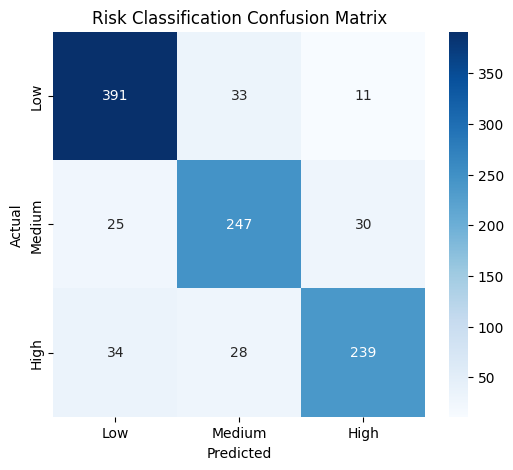

In [12]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Risk Classification Confusion Matrix")
plt.show()

### Overall Model Perfromance
- Achieved 84% accuracy on unseen validation data

- Balanced performance across all risk categories

- No major class bias observed

**Conclusion:** The fine-tuned BERT model generalizes well for legal risk classification.

### Low Risk Clauses
- Precision: 87% | Recall: 90%

- Most low-risk clauses are correctly identified

- Very few risky clauses are wrongly marked as low risk

**Insights:** The model is highly reliable at recognizing safe contractual clauses.

### Medium Risk Clauses

- Precision: 80% | Recall: 82%

- Some confusion with high and low risk (due to overlap in legal language)

**Insights:** Medium-risk clauses are the hardest category, but still classified accurately.

### High Risk Clauses

- Precision: 85% | Recall: 79%

- Majority of dangerous clauses correctly detected

- Small portion misclassified as medium or low risk

**Insights:** The model effectively captures high-risk contractual patterns.

### Confusion Matrix Insights

- Strong diagonal values → most predictions are correct

- Misclassifications mostly occur between Medium ↔ High

- Very few extreme errors (High classified as Low is rare)

**Insights:** Errors occur mainly between adjacent risk levels, which is acceptable in real-world risk scoring systems.

### Conclusion
The fine-tuned BERT model achieved strong performance with 84% accuracy and balanced precision-recall across risk categories. Confusion primarily occurred between medium and high risk clauses, reflecting natural semantic overlap in legal language, while extreme misclassifications were minimal.